# Malaria, Typhoid, and Co-Infection Classification Using Machine Learning

## 1. Problem Definition and Project Scope

### 1.1 Background

Malaria and typhoid fever can present with overlapping symptoms, including fever, headache, fatigue, and general weakness. In settings where confirmatory laboratory testing is limited, this overlap can complicate preliminary clinical assessment. Incorrect classification may contribute to delayed treatment, unnecessary medication, avoidable cost, and antimicrobial misuse.

This notebook investigates whether machine-learning models can distinguish among three labelled outcomes: **Malaria**, **Typhoid**, and **Both (co-infection)** using reported symptoms and basic vital signs.

> **Scope statement:** The dataset used in this project is synthetic. Consequently, the analysis is a methodological benchmark and not clinical evidence. The resulting model must not be used to diagnose or treat patients.

### 1.2 Problem Statement

The modelling task is a three-class classification problem in which symptom overlap and severe class imbalance make co-infection particularly difficult to identify. The central technical question is whether an interpretable model can achieve useful class-level discrimination without relying on laboratory measurements or synthetic shortcut variables.

### 1.3 Project Objective

The project aims to:

1. examine the distribution and statistical relationships of symptoms and basic vital signs;
2. construct a reproducible, leakage-safe modelling workflow;
3. compare linear and nonlinear classifiers under stratified cross-validation;
4. prioritize macro F1 and balanced accuracy so that minority-class performance is not hidden by overall accuracy; and
5. identify the strongest candidate for further validation on real, laboratory-confirmed data.

### 1.4 Analytical Success Criteria

A model is considered comparatively successful within this synthetic benchmark when it:

- achieves the highest cross-validated macro F1 among the evaluated candidates;
- maintains acceptable precision and recall for each class, especially co-infection;
- demonstrates similar cross-validation and locked-holdout performance; and
- remains interpretable and practical for a low-resource decision-support setting.

Clinical success cannot be established from this dataset. It would require external validation, calibration assessment, prospective impact evaluation, and comparison against laboratory-confirmed reference diagnoses.

## 2. Data Understanding and Exploratory Analysis

This section evaluates dataset structure, data quality, class balance, feature distributions, redundancy, and statistical associations before model development. Exploratory findings describe the synthetic dataset only and should not be interpreted as population-level clinical relationships.

In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.neural_network import MLPClassifier
import joblib
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

# Set style for better visuals
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)



In [2]:
#import dataset
df = pd.read_csv('..\dataset\synthetic_malaria_typhoid_dataset.csv')
df.head(20)

,Fever,Fatigue,Weakness,Loss_of_Appetite,Weight_Loss,Sweating,Chills,Headache,Muscle_Pain,Joint_Pain,...,Back_Pain,Dehydration,Swelling_Feet,Condition,Temperature,Heart_Rate,Platelet_Count,Noise,Symptom_Count,Severity_Index
0,0,1,1,0,0,1,0,1,0,1,...,1,1,0,Malaria,38.700062,88.942549,59.489171,0.713331,26,14.300335
1,1,1,1,0,1,1,0,1,1,1,...,1,0,0,Malaria,38.838868,62.597873,90.769641,0.737259,25,14.117643
2,1,0,0,1,1,0,0,1,0,0,...,1,0,0,Typhoid,37.298361,78.457597,219.442320,0.076410,21,13.272067
3,0,0,0,0,0,1,0,0,1,0,...,0,0,1,Typhoid,38.156407,79.601317,231.637991,0.299896,13,12.661358
4,0,1,1,1,1,1,1,1,1,1,...,0,1,0,Malaria,37.678278,78.766706,160.078422,0.720573,22,13.475015
5,1,1,0,0,1,0,0,1,0,1,...,1,0,0,Malaria,38.910786,96.197224,117.922478,0.824498,19,13.618238
6,0,0,0,0,1,0,1,0,1,1,...,0,0,1,Typhoid,38.496386,73.197696,222.986394,0.855459,19,13.368120
7,1,1,1,1,1,1,0,1,1,0,...,1,0,0,Malaria,39.005593,90.469111,151.105491,0.237782,22,13.954676
8,0,0,1,0,1,1,1,1,1,1,...,0,1,1,Typhoid,37.531035,99.531038,201.601559,0.431766,26,13.851401
9,1,0,1,0,0,0,0,1,0,1,...,1,1,0,Malaria,37.537999,77.572629,167.448400,0.043497,19,13.181002


In [3]:
# shape of the dataset
df.shape

(50000, 48)

In [4]:
# data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 48 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Fever                50000 non-null  int64  
 1   Fatigue              50000 non-null  int64  
 2   Weakness             50000 non-null  int64  
 3   Loss_of_Appetite     50000 non-null  int64  
 4   Weight_Loss          50000 non-null  int64  
 5   Sweating             50000 non-null  int64  
 6   Chills               50000 non-null  int64  
 7   Headache             50000 non-null  int64  
 8   Muscle_Pain          50000 non-null  int64  
 9   Joint_Pain           50000 non-null  int64  
 10  Dizziness            50000 non-null  int64  
 11  Paleness             50000 non-null  int64  
 12  Nausea               50000 non-null  int64  
 13  Vomiting             50000 non-null  int64  
 14  Abdominal_Pain       50000 non-null  int64  
 15  Diarrhea             50000 non-null 

In [5]:
# summary statistics
df.describe()

,Fever,Fatigue,Weakness,Loss_of_Appetite,Weight_Loss,Sweating,Chills,Headache,Muscle_Pain,Joint_Pain,...,Burning_Urine,Back_Pain,Dehydration,Swelling_Feet,Temperature,Heart_Rate,Platelet_Count,Noise,Symptom_Count,Severity_Index
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.489240,0.595880,0.682140,0.523520,0.452640,0.387880,0.396560,0.661360,0.511220,0.686620,...,0.379540,0.522740,0.583200,0.432260,38.597808,92.608607,156.902453,0.498180,21.184880,13.725947
std,0.499889,0.490726,0.465649,0.499451,0.497757,0.487272,0.489188,0.473252,0.499879,0.463872,...,0.485277,0.499488,0.493034,0.495395,0.621943,12.880527,43.351194,0.287879,3.198422,0.389634
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,36.051406,35.094926,-12.466788,0.000010,9.000000,12.021781
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,38.181953,84.060235,127.476845,0.249156,19.000000,13.464276
50%,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,38.598613,92.765931,156.490979,0.497002,21.000000,13.722674
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,39.022031,101.316700,185.584377,0.746753,23.000000,13.983592
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,41.186337,150.149940,350.324790,0.999996,36.000000,15.621773


In [6]:
#missing values
df.isnull().sum()


Fever                  0
Fatigue                0
Weakness               0
Loss_of_Appetite       0
Weight_Loss            0
Sweating               0
Chills                 0
Headache               0
Muscle_Pain            0
Joint_Pain             0
Dizziness              0
Paleness               0
Nausea                 0
Vomiting               0
Abdominal_Pain         0
Diarrhea               0
Constipation           0
Bloating               0
Confusion              0
Insomnia               0
Seizures               0
Irritability           0
Cough                  0
Shortness_of_Breath    0
Chest_Pain             0
Sore_Throat            0
Anemia                 0
Jaundice               0
Bleeding_Gums          0
Bruising               0
Rash                   0
Itching                0
Yellow_Eyes            0
Eye_Pain               0
Blurred_Vision         0
Dark_Urine             0
Frequent_Urination     0
Burning_Urine          0
Back_Pain              0
Dehydration            0


In [7]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

### 2.1 Target-Class Distribution

The target variable, `Condition`, contains three mutually exclusive labels: Malaria, Typhoid, and Both. Class frequencies are examined first because imbalance directly affects metric selection, cross-validation, and model behavior.

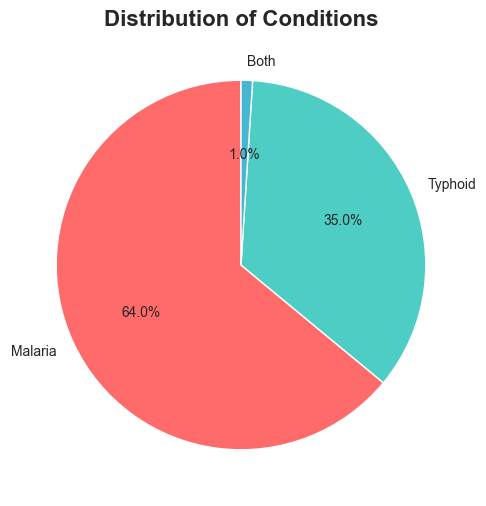

Class distribution:
Condition
Malaria    32000
Typhoid    17500
Both         500
Name: count, dtype: int64

Class balance ratio: 0.016


In [8]:
# Target distribution
plt.figure(figsize=(10, 6))
target_counts = df['Condition'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
plt.pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
plt.title('Distribution of Conditions', fontsize=16, fontweight='bold')
plt.show()

print("Class distribution:")
print(target_counts)
print(f"\nClass balance ratio: {target_counts.min()/target_counts.max():.3f}")

#### Interpretation

The target distribution is strongly imbalanced:

- **Malaria:** 64%
- **Typhoid:** 35%
- **Both:** 1%

Overall accuracy would therefore be misleading: a model could perform well on the two majority classes while failing to identify co-infection. Subsequent evaluation emphasizes macro-averaged metrics, balanced accuracy, per-class precision and recall, and the confusion matrix.

### 2.2 Temperature Distribution by Condition

Temperature is assessed using distribution plots and a group-comparison test. Visual inspection provides information about overlap and outliers, while the statistical test evaluates whether group means differ within the generated sample.

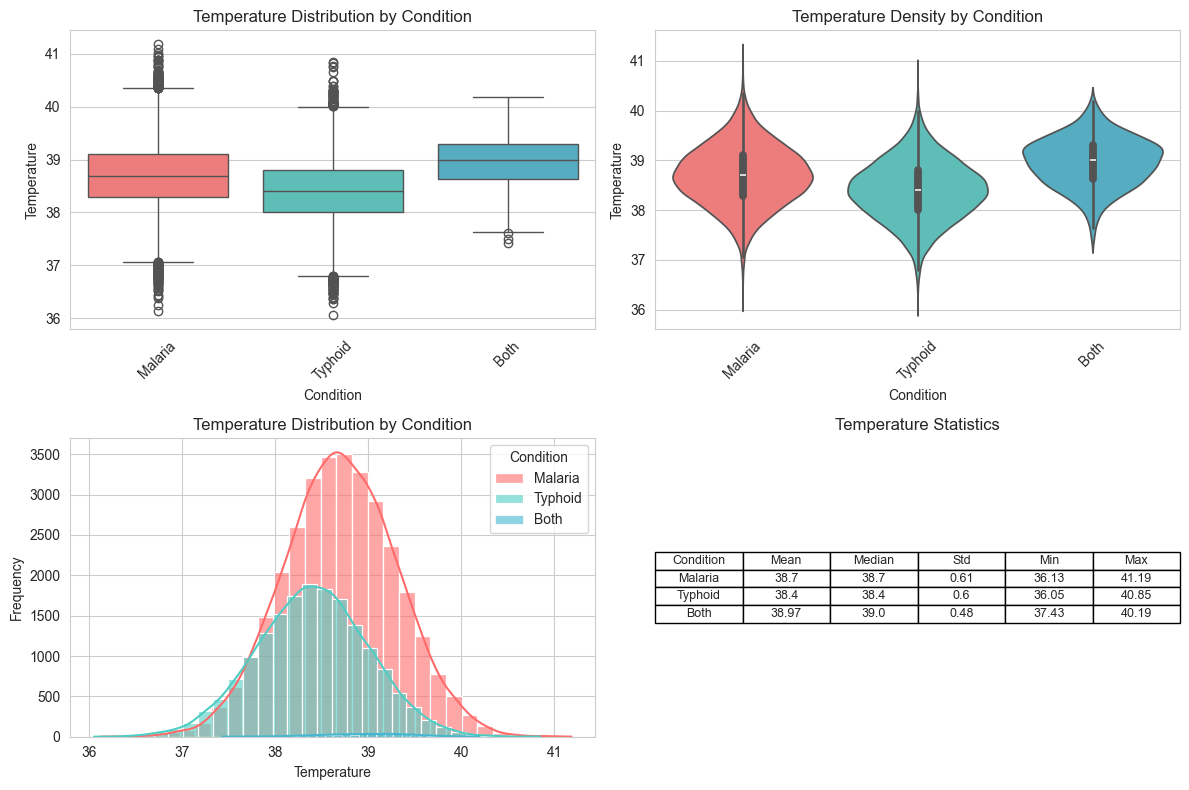


ANOVA Test for Temperature Across Conditions:
F-statistic: 1494.320
p-value: 0.0000e+00


In [ ]:
# Set up figure for multiple subplots
plt.figure(figsize=(12, 8))

# Box Plot
plt.subplot(2, 2, 1)
sns.boxplot(x='Condition', y='Temperature', data=df, palette=colors)
plt.title('Temperature Distribution by Condition', fontsize=12)
plt.xlabel('Condition')
plt.ylabel('Temperature')
plt.xticks(rotation=45)

# Violin Plot
plt.subplot(2, 2, 2)
sns.violinplot(x='Condition', y='Temperature', data=df, palette=colors)
plt.title('Temperature Density by Condition', fontsize=12)
plt.xlabel('Condition')
plt.ylabel('Temperature')
plt.xticks(rotation=45)

# Histogram with KDE Overlay
plt.subplot(2, 2, 3)
for condition, color in zip(df['Condition'].unique(), colors):
    subset = df[df['Condition'] == condition]
    sns.histplot(subset['Temperature'], kde=True, 
                 color=color, alpha=0.6, bins=30, label=condition)
plt.title('Temperature Distribution by Condition', fontsize=12)
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.legend(title='Condition')

# Statistical Summary Table
plt.subplot(2, 2, 4)
stats_data = []

# Compute key descriptive statistics for each condition
for condition in df['Condition'].unique():
    temp_data = df[df['Condition'] == condition]['Temperature']
    stats_data.append({
        'Condition': condition,
        'Mean': temp_data.mean(),
        'Median': temp_data.median(),
        'Std': temp_data.std(),
        'Min': temp_data.min(),
        'Max': temp_data.max()
    })

# Convert to DataFrame for display
stats_df = pd.DataFrame(stats_data)

# Display statistics as a table
plt.table(cellText=stats_df.round(2).values,
          colLabels=stats_df.columns,
          cellLoc='center',
          loc='center')
plt.axis('off')
plt.title('Temperature Statistics', fontsize=12)

# Adjust layout and show all subplots
plt.tight_layout()
plt.show()

# ANOVA Test for Temperature Differences
# Compare mean temperature across conditions
groups = [df[df['Condition'] == condition]['Temperature'] for condition in df['Condition'].unique()]
f_stat, p_value = stats.f_oneway(*groups)

print("\nANOVA Test for Temperature Across Conditions:")
print(f"F-statistic: {f_stat:.3f}")
print(f"p-value: {p_value:.4e}")

# Interpretation:
# If p-value < 0.05, there is a statistically significant difference
# in mean temperature among the conditions.


#### Interpretation of Temperature Results

The generated temperature distributions differ across the three target classes, and the ANOVA result indicates statistically detectable differences in group means. Because the dataset contains 50,000 observations, statistical significance alone should not be treated as evidence of strong predictive or clinical value.

The distributions and their overlap are more informative for modelling: temperature may contribute useful signal, but it should be evaluated jointly with symptoms and validated through out-of-sample performance. The observed separation reflects assumptions built into the synthetic data generator and does not establish a real-world diagnostic relationship.

### 2.3 Binary Symptom Prevalence

Only genuine binary symptom indicators are included in this analysis. Continuous measurements and engineered fields are deliberately excluded so that the plotted means can be interpreted correctly as the proportion of records in which each symptom is present.

<Figure size 1600x800 with 0 Axes>

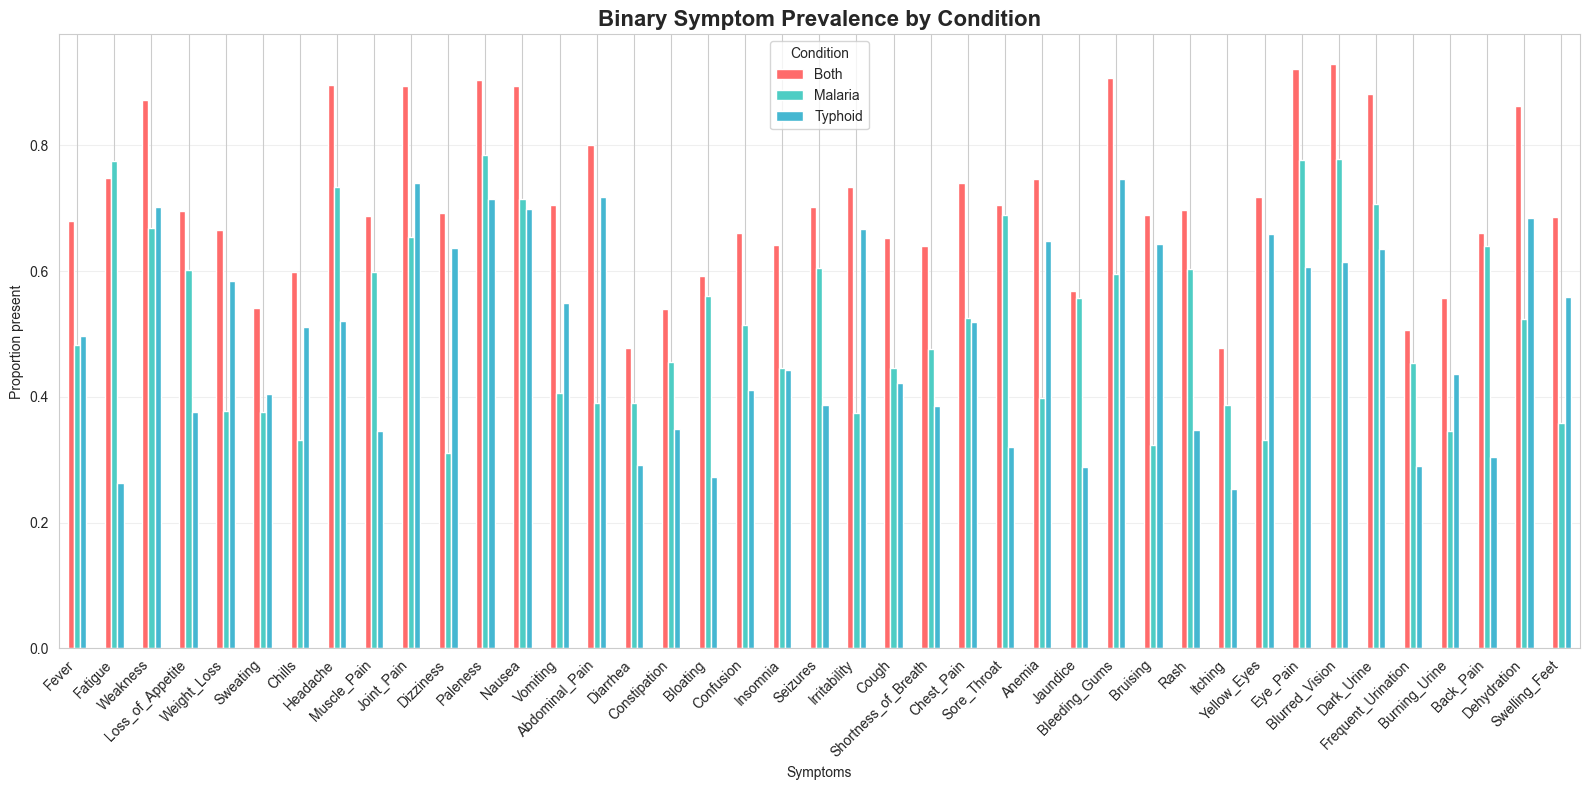

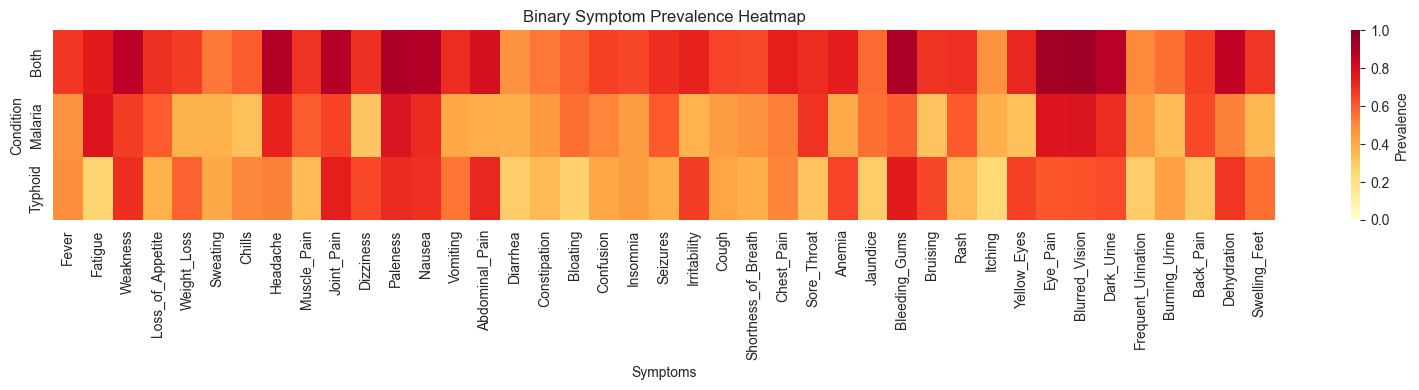

In [10]:

# Identify true binary symptom flags only.
symptom_columns = [
    column for column in df.columns
    if column != "Condition"
    and set(df[column].dropna().unique()).issubset({0, 1})
]

symptom_prevalence = df.groupby("Condition")[symptom_columns].mean().T

plt.figure(figsize=(16, 8))
symptom_prevalence.plot(kind="bar", figsize=(16, 8), color=colors)
plt.title("Binary Symptom Prevalence by Condition", fontsize=16, fontweight="bold")
plt.xlabel("Symptoms")
plt.ylabel("Proportion present")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 4))
sns.heatmap(
    symptom_prevalence.T,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Prevalence"},
)
plt.title("Binary Symptom Prevalence Heatmap")
plt.xlabel("Symptoms")
plt.ylabel("Condition")
plt.tight_layout()
plt.show()


### 2.4 Feature Redundancy and Correlation

Pearson correlation is used here to examine redundancy among numeric predictors. The nominal target is not converted into arbitrary numeric codes, because correlations with such codes would depend on the chosen label ordering and would not have a valid directional interpretation.

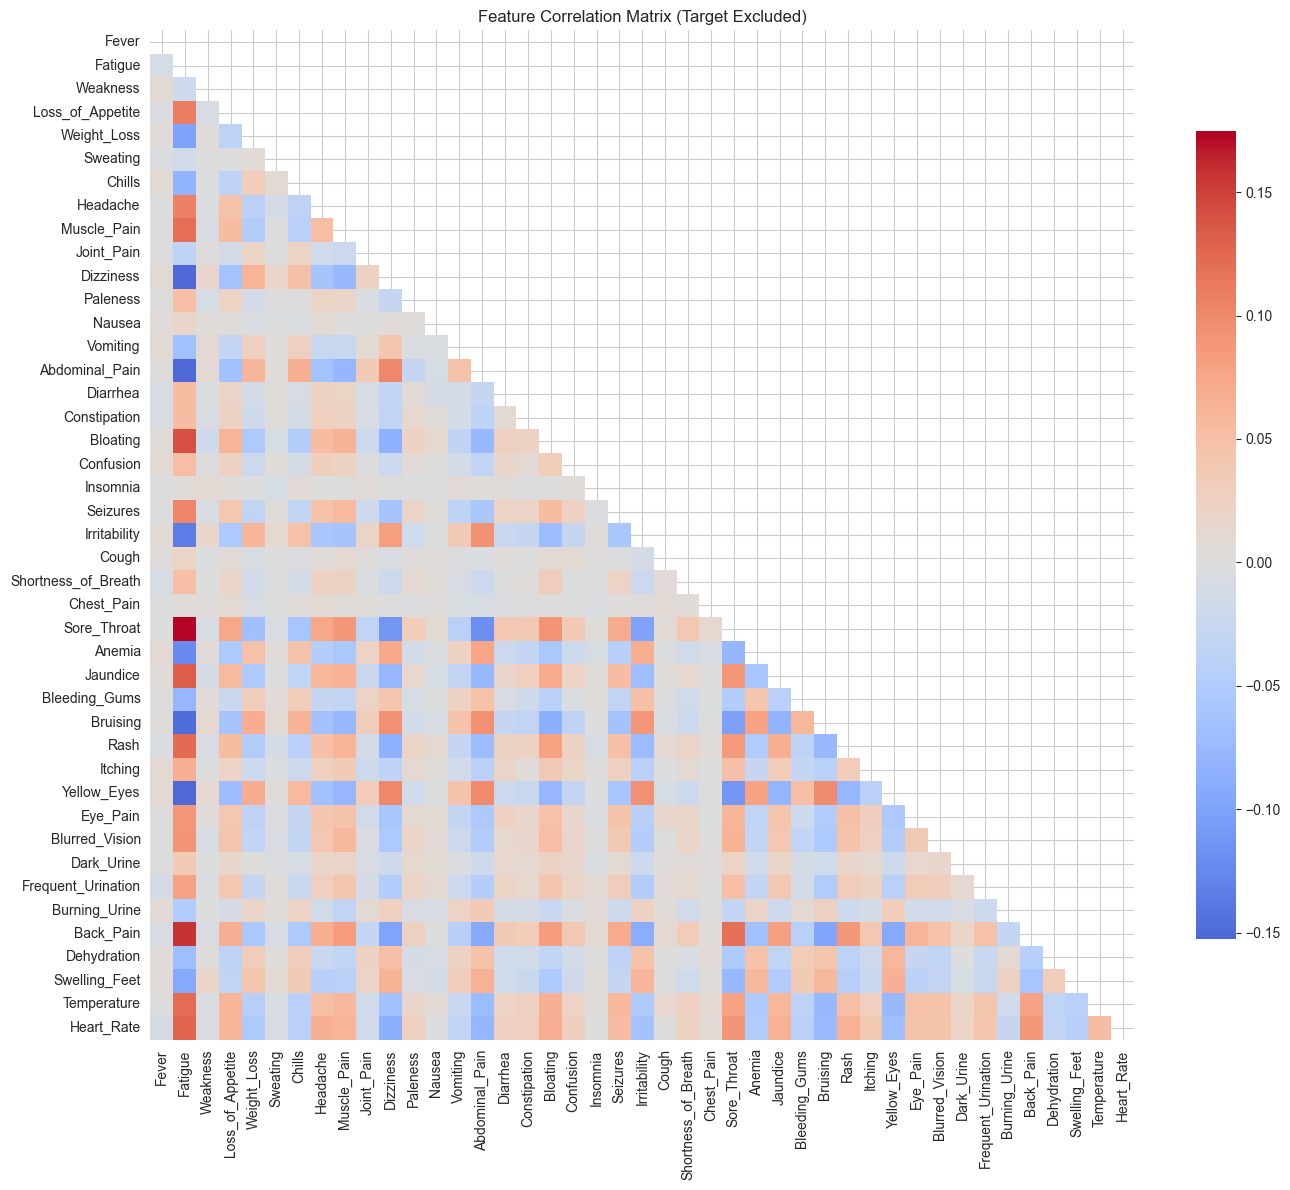

,Feature_1,Feature_2,Absolute_Correlation
0,Fatigue,Sore_Throat,0.174665
1,Fatigue,Back_Pain,0.157604
2,Fatigue,Yellow_Eyes,0.152460
3,Fatigue,Abdominal_Pain,0.152431
4,Fatigue,Dizziness,0.150006
5,Fatigue,Bruising,0.147867
6,Fatigue,Bloating,0.140963
7,Fatigue,Irritability,0.134724
8,Fatigue,Jaundice,0.131954
9,Fatigue,Heart_Rate,0.126399


In [11]:

# Correlation is used only for numeric feature redundancy.
# The nominal diagnosis is deliberately not converted to arbitrary numbers.
numeric_features = symptom_columns + ["Temperature", "Heart_Rate"]
corr_matrix = df[numeric_features].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    square=False,
    cbar_kws={"shrink": 0.8},
)
plt.title("Feature Correlation Matrix (Target Excluded)")
plt.tight_layout()
plt.show()

upper = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant_pairs = (
    upper.stack()
    .rename("Absolute_Correlation")
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2"})
)
display(redundant_pairs)


#### Interpretation of the Correlation Analysis

The correlation matrix identifies predictor pairs that carry similar information. Strong absolute correlations may indicate redundancy, measurement overlap, or derived relationships. These pairs warrant attention because redundant predictors can destabilize linear-model coefficients and complicate interpretation.

Correlation does not measure feature importance, causality, or association with the nominal diagnosis. Target-related evidence is assessed separately using appropriate categorical association tests and out-of-sample model evaluation.

### 2.5 Principal Component Analysis

Principal Component Analysis (PCA) provides a two-dimensional view of the deployable feature space. The transformation is based on standardized binary symptoms, temperature, and heart rate; laboratory and synthetic shortcut variables are excluded.

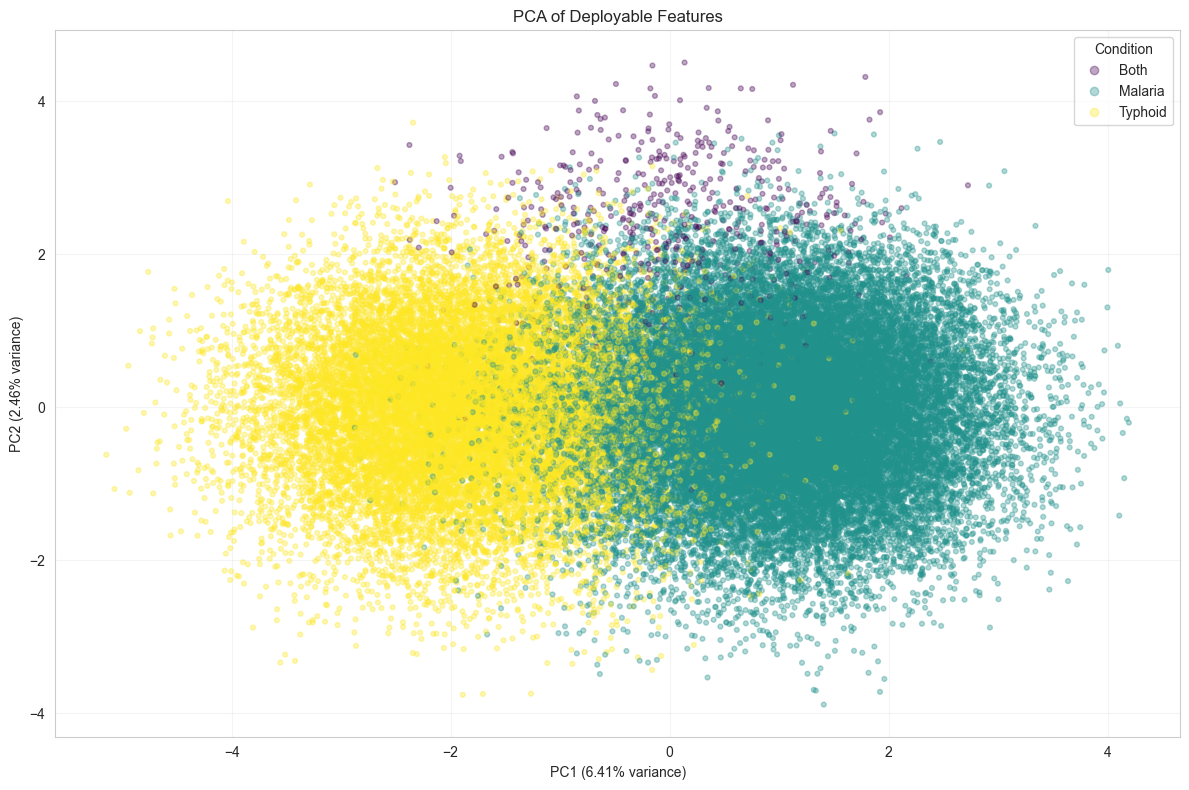

Variance explained by two components: 8.88%


In [12]:

# PCA is exploratory only and uses deployable symptoms/basic vitals.
X_pca_source = df[symptom_columns + ["Temperature", "Heart_Rate"]]
X_scaled = StandardScaler().fit_transform(X_pca_source)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

condition_codes, condition_names = pd.factorize(df["Condition"], sort=True)
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=condition_codes,
    cmap="viridis",
    alpha=0.35,
    s=12,
)
handles, _ = scatter.legend_elements()
plt.legend(handles, condition_names, title="Condition")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.title("PCA of Deployable Features")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print(f"Variance explained by two components: {pca.explained_variance_ratio_.sum():.2%}")


#### Interpretation of the PCA Projection

The first two principal components explain only a small proportion of total variance. Substantial overlap in the two-dimensional projection therefore does not prove that the classes are inseparable; it shows that two linear components do not summarize the high-dimensional structure well.

PCA is used here for visualization rather than model selection. Predictive models retain the full approved feature set, allowing them to use information that is not visible in this projection.

### 2.6 Symptom Burden and Co-Occurrence Patterns

This analysis compares total reported symptom burden across classes and examines correlation among frequently observed symptoms. It is intended to reveal broad structural patterns and potential redundancy rather than establish disease mechanisms.

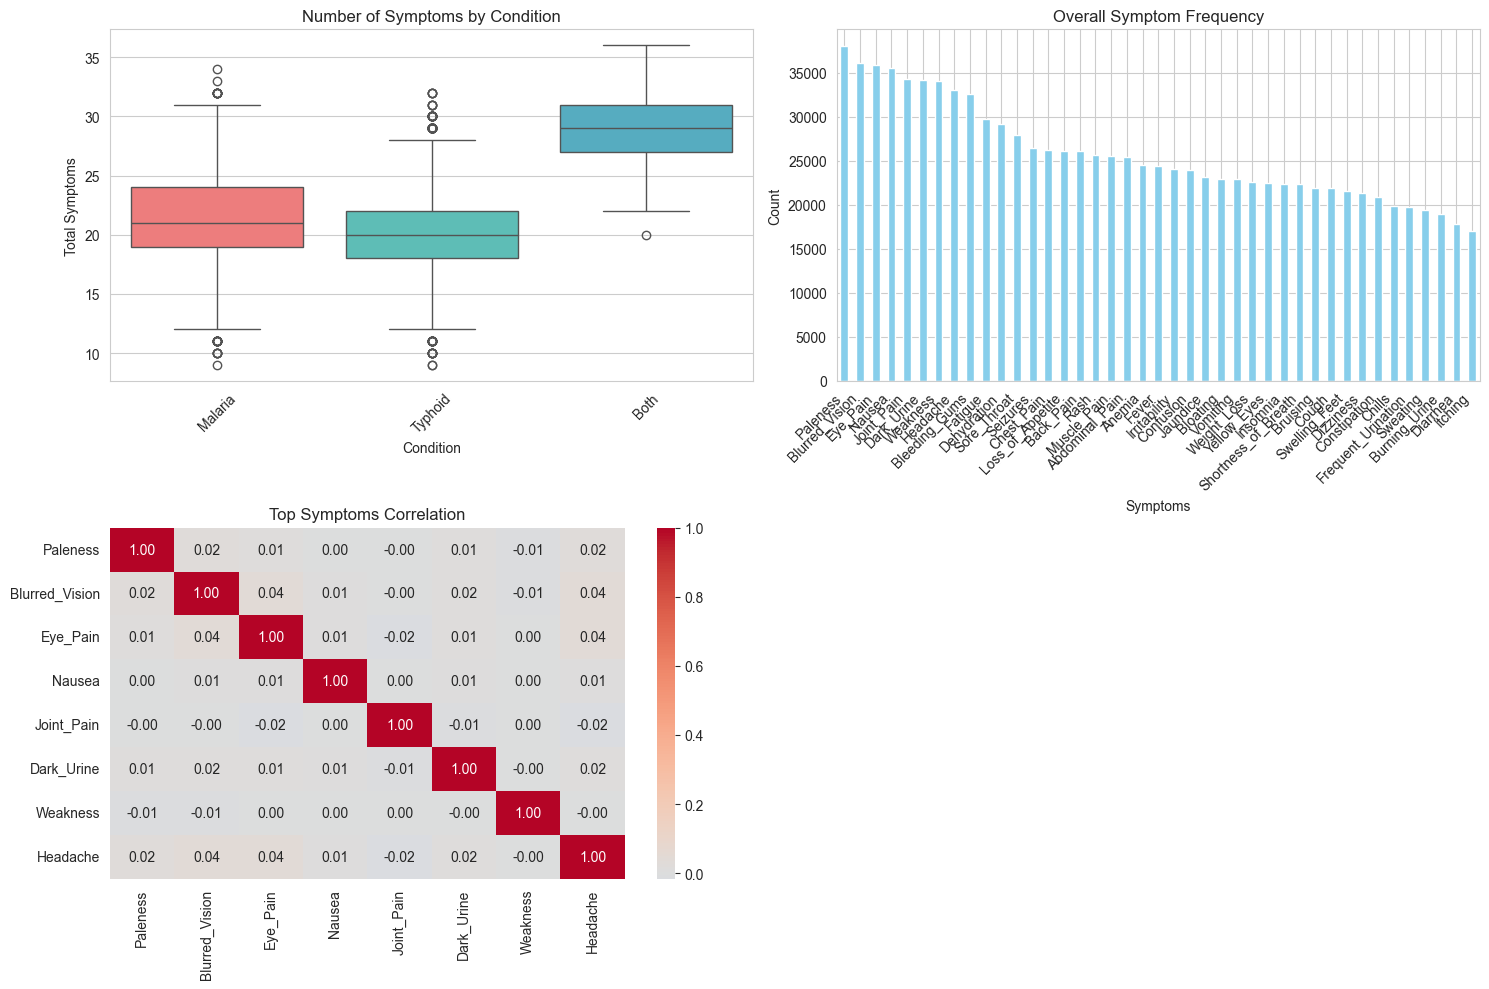

In [ ]:
# Compute Total Symptoms per Patient
plt.figure(figsize=(15, 10))

# Sum across all symptom columns to count how many symptoms each patient has
df['Total_Symptoms'] = df[symptom_columns].sum(axis=1)

# Box plot: compare number of symptoms across medical conditions
plt.subplot(2, 2, 1)
sns.boxplot(x='Condition', y='Total_Symptoms', data=df, palette=colors)
plt.title('Number of Symptoms by Condition', fontsize=12)
plt.xlabel('Condition')
plt.ylabel('Total Symptoms')
plt.xticks(rotation=45)

# Prepare Data for Association Rule Mining
from mlxtend.frequent_patterns import apriori, association_rules

# Convert symptom data to boolean format (True = symptom present)
df_bool = df[symptom_columns].astype(bool)

# Symptom Frequency Overview
plt.subplot(2, 2, 2)
symptom_counts = df[symptom_columns].sum().sort_values(ascending=False)

# Plot frequency of each symptom
symptom_counts.plot(kind='bar', color='skyblue')
plt.title('Overall Symptom Frequency', fontsize=12)
plt.xlabel('Symptoms')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Symptom Correlation Heatmap (Simplified Network)
plt.subplot(2, 2, 3)

# Focus on top 8 most frequent symptoms for clearer visualization
top_symptoms = symptom_counts.head(8).index
top_corr = df[top_symptoms].corr()

# Display correlation among top symptoms
sns.heatmap(
    top_corr, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0
)
plt.title('Top Symptoms Correlation', fontsize=12)

# Adjust layout
plt.tight_layout()
plt.show()

# Interpretation
# - The first plot shows how the total number of symptoms varies across conditions.
# - The bar chart reveals which symptoms are most frequently reported overall.
# - The heatmap highlights relationships among top symptoms 
#   (e.g., symptoms that often occur together).
# - Next steps could include applying association rule mining (Apriori)
#   to identify common symptom combinations across conditions.


#### Interpretation of Symptom Patterns

Differences in total symptom counts are visible across the generated classes, with co-infection tending to contain more positive symptom indicators. This pattern must be interpreted cautiously because the synthetic generator explicitly assigns co-infection higher average symptom probabilities; it is partly a design property rather than an independently discovered clinical finding.

The symptom-correlation heatmap highlights features that frequently move together. Highly correlated symptoms may provide overlapping information, but they should not be removed solely from pairwise correlation. Their value is assessed within the cross-validated modelling pipeline.

### 2.7 Statistical Association of Binary Symptoms

Chi-square tests evaluate whether each binary symptom is independent of the target class. Cramer's V quantifies association strength, while Bonferroni-adjusted p-values control the family-wise error rate across multiple symptom tests.

In [14]:

# Chi-square association tests for binary symptoms only.
# Bonferroni adjustment controls the family-wise error rate.
chi_square_rows = []
for symptom in symptom_columns:
    table = pd.crosstab(df[symptom], df["Condition"])
    chi2, p_value, dof, expected = stats.chi2_contingency(table)
    n = table.to_numpy().sum()
    denominator = n * (min(table.shape) - 1)
    effect_size = np.sqrt(chi2 / denominator) if denominator else 0.0
    chi_square_rows.append({
        "Symptom": symptom,
        "Chi2": chi2,
        "P_Value": p_value,
        "Cramers_V": effect_size,
    })

association_results = pd.DataFrame(chi_square_rows)
association_results["Adjusted_P_Value"] = np.minimum(
    association_results["P_Value"] * len(association_results),
    1.0,
)
association_results["Significant"] = association_results["Adjusted_P_Value"] < 0.05
association_results = association_results.sort_values(
    ["Cramers_V", "Adjusted_P_Value"],
    ascending=[False, True],
)
display(association_results.head(15))


,Symptom,Chi2,P_Value,Cramers_V,Adjusted_P_Value,Significant
1,Fatigue,12443.668643,0.0,0.498872,0.0,True
25,Sore_Throat,6284.440288,0.0,0.354526,0.0,True
38,Back_Pain,5129.247099,0.0,0.320289,0.0,True
10,Dizziness,5076.549807,0.0,0.318639,0.0,True
32,Yellow_Eyes,5058.607496,0.0,0.318076,0.0,True
14,Abdominal_Pain,4991.601742,0.0,0.315962,0.0,True
29,Bruising,4826.083542,0.0,0.310679,0.0,True
21,Irritability,3995.672562,0.0,0.282690,0.0,True
17,Bloating,3793.852051,0.0,0.275458,0.0,True
27,Jaundice,3279.142165,0.0,0.256091,0.0,True


#### Interpretation of Chi-Square and Effect-Size Results

Several symptoms show statistically significant class associations after multiple-testing correction. With a large synthetic sample, very small p-values are expected even for modest differences; effect size is therefore more useful than significance alone.

Cramer's V ranks the strength of association within this dataset, but it does not indicate direction, causality, or standalone diagnostic performance. Rankings should be described as properties of the synthetic generator and confirmed through cross-validated predictive evaluation.

### 2.8 Temperature-Symptom Interactions

Temperature distributions are compared within records containing the most strongly associated binary symptoms. This conditional view examines whether temperature contributes additional class separation when patients share a symptom.

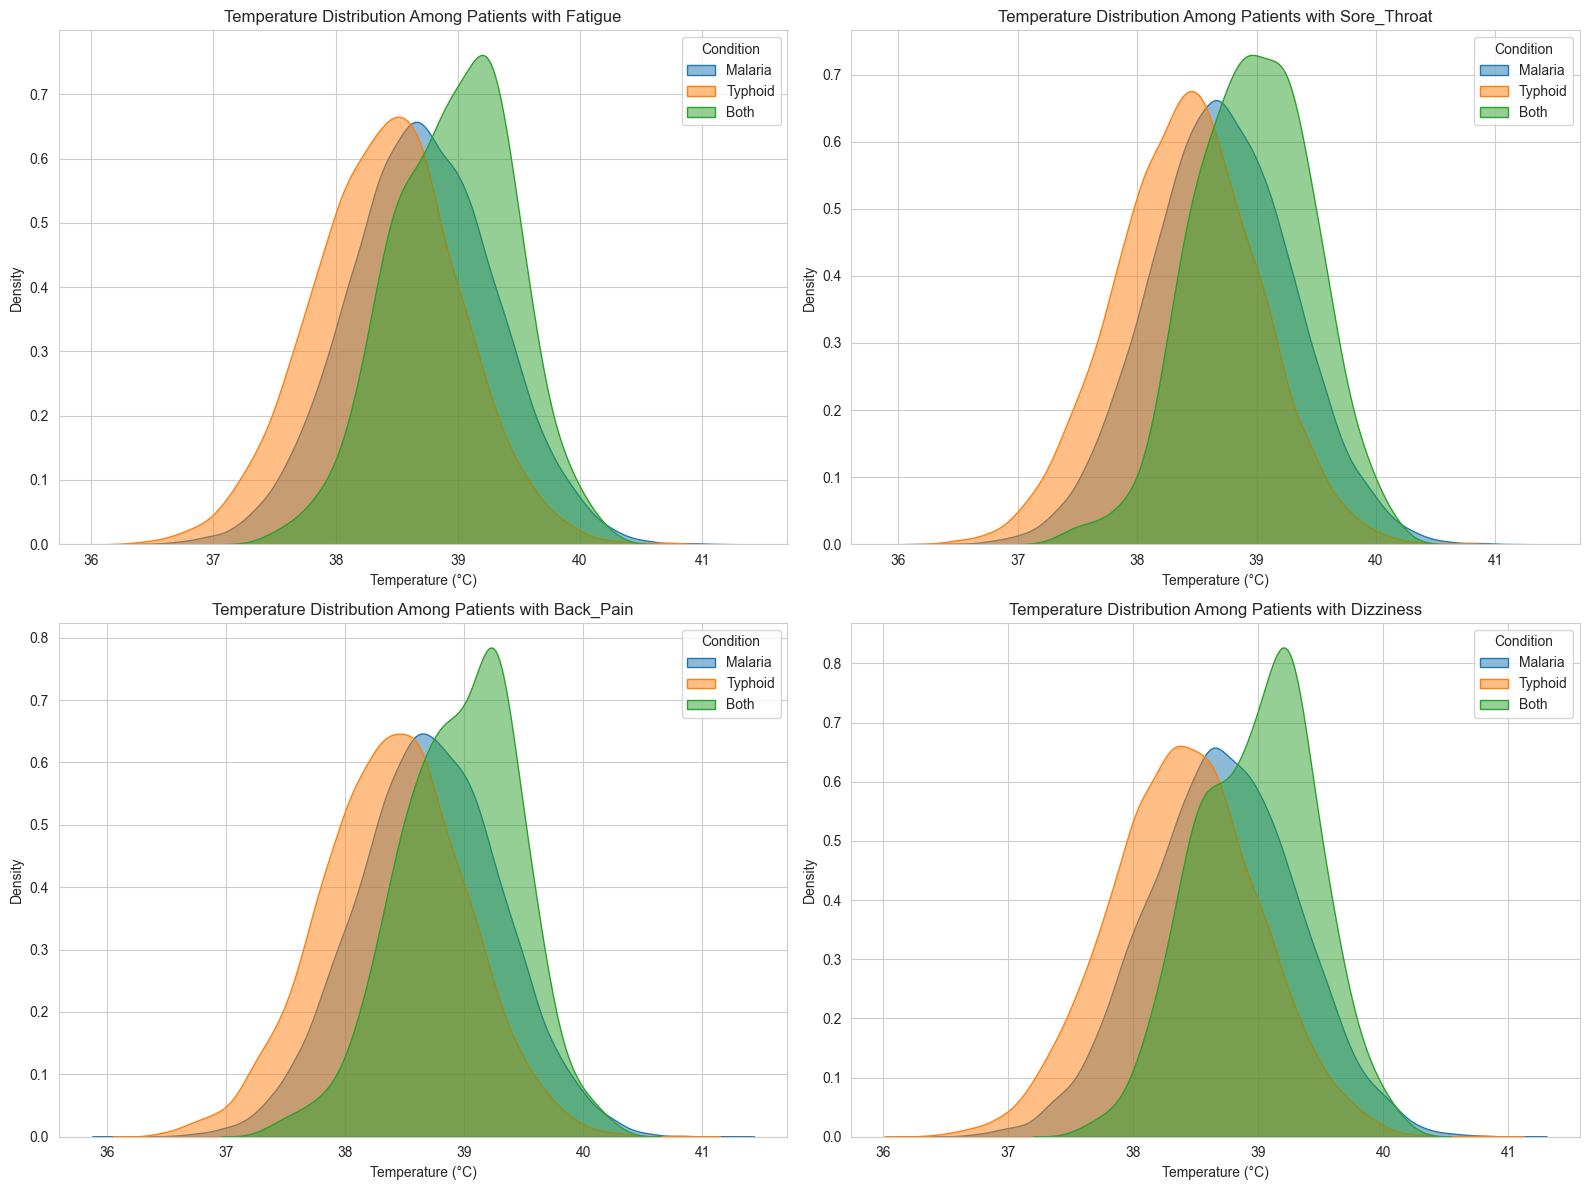

In [ ]:
# Setup Visualization
plt.figure(figsize=(16, 12))

# Select top 4 symptoms significantly associated with condition
significant_symptoms = association_results[association_results['Significant']].head(4)['Symptom'].tolist()

# Plot Temperature Distributions for Each Symptom
for i, symptom in enumerate(significant_symptoms, 1):
    plt.subplot(2, 2, i)
    
    # Plot temperature density per condition for patients showing this symptom
    for condition in df['Condition'].unique():
        subset = df[(df['Condition'] == condition) & (df[symptom] == 1)]
        sns.kdeplot(
            subset['Temperature'], 
            label=condition, 
            fill=True, 
            alpha=0.5
        )
    
    plt.title(f'Temperature Distribution Among Patients with {symptom}', fontsize=12)
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Density')
    plt.legend(title='Condition')

plt.tight_layout()
plt.show()

# Interpretation
# - Each subplot shows how temperature varies across conditions 
#   for patients exhibiting a particular significant symptom.
# - Peaks in density curves reveal characteristic temperature ranges 
#   associated with each condition.
# - Overlapping curves suggest similar thermal profiles, 
#   while separation indicates distinct patterns.
# - This helps understand physiological differences between conditions 
#   when certain symptoms are present.


#### Interpretation of Temperature-Symptom Interactions

Temperature distributions continue to show class-dependent differences within several symptom-defined subsets. This suggests that temperature and symptom indicators may provide complementary predictive information in the generated dataset.

The plots are exploratory and do not control for confounding variables or establish independence in a statistical sense. Their practical contribution is tested by the complete model pipeline rather than inferred from visual separation alone.

,Symptom,Cramers_V,Adjusted_P_Value
0,Fatigue,0.498872,0.000000e+00
1,Sore_Throat,0.354526,0.000000e+00
2,Back_Pain,0.320289,0.000000e+00
3,Dizziness,0.318639,0.000000e+00
4,Yellow_Eyes,0.318076,0.000000e+00
5,Abdominal_Pain,0.315962,0.000000e+00
6,Bruising,0.310679,0.000000e+00
7,Irritability,0.282690,0.000000e+00
8,Bloating,0.275458,0.000000e+00
9,Jaundice,0.256091,0.000000e+00


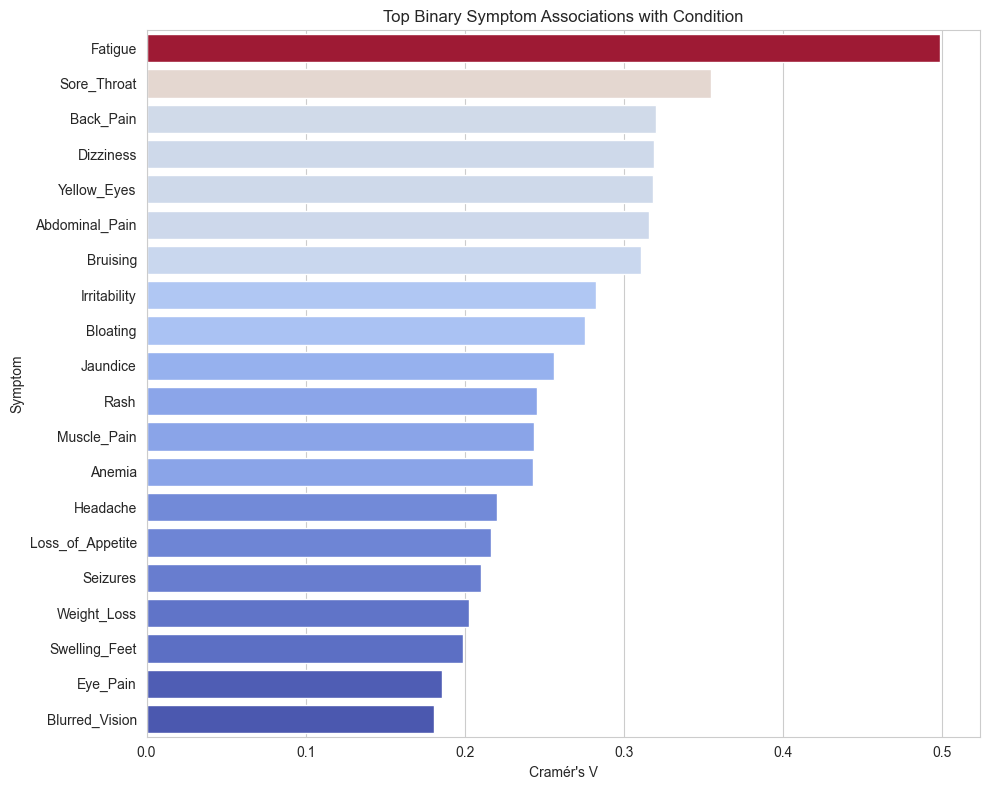

In [16]:

# Cramér's V is valid here because every input is a binary symptom.
cramer_df = (
    association_results[["Symptom", "Cramers_V", "Adjusted_P_Value"]]
    .sort_values("Cramers_V", ascending=False)
    .reset_index(drop=True)
)
display(cramer_df)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=cramer_df.head(20),
    x="Cramers_V",
    y="Symptom",
    hue="Cramers_V",
    palette="coolwarm",
    legend=False,
)
plt.title("Top Binary Symptom Associations with Condition")
plt.xlabel("Cramér's V")
plt.ylabel("Symptom")
plt.tight_layout()
plt.show()


### 2.9 Cramer's V Ranking

Cramer's V is calculated only for binary symptom indicators against the categorical target. Continuous variables are excluded because treating nearly unique measurements as contingency-table categories would produce misleading association estimates.

Higher values identify symptoms whose prevalence differs more strongly across the generated classes. Lower values indicate limited marginal differentiation. These rankings are descriptive, not causal, and do not replace multivariable evaluation. In particular, a weak marginal association does not imply that a symptom is useless when combined with other predictors.

## 3. Model Development and Evaluation

The modelling stage compares interpretable and nonlinear classifiers under a common experimental protocol. All preprocessing and hyperparameter selection occur within the training partition, and a locked holdout set is reserved for final evaluation.

In [ ]:

# Re-load a clean copy so results do not depend on mutations in earlier cells.
from pathlib import Path
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import loguniform, randint, uniform

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score, log_loss,
    precision_score, recall_score, roc_auc_score
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
TARGET = "Condition"

notebook_dir = Path.cwd().resolve()
project_root = notebook_dir.parent if notebook_dir.name.lower() == "modelling" else notebook_dir
data_path = project_root / "dataset" / "synthetic_malaria_typhoid_dataset.csv"
df_model = pd.read_csv(data_path)

# Detect genuine binary symptom flags instead of treating every numeric field as a symptom.
binary_symptoms = [
    column for column in df_model.columns
    if column != TARGET
    and set(df_model[column].dropna().unique()).issubset({0, 1})
]

deployable_vitals = ["Temperature", "Heart_Rate"]
excluded_features = [
    "Platelet_Count", "Noise", "Symptom_Count", "Total_Symptoms", "Severity_Index"
]
model_features = binary_symptoms + [
    column for column in deployable_vitals if column in df_model.columns
]

X = df_model[model_features].copy()
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_model[TARGET])

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Class mapping:", dict(enumerate(label_encoder.classes_)))
print("Training rows:", len(X_train), "| Locked holdout rows:", len(X_holdout))
print("Features used:", len(model_features))
print("Excluded fields:", [c for c in excluded_features if c in df_model.columns])


Class mapping: {0: 'Both', 1: 'Malaria', 2: 'Typhoid'}
Training rows: 40000 | Locked holdout rows: 10000
Features used: 43
Excluded fields: ['Platelet_Count', 'Noise', 'Symptom_Count', 'Severity_Index']


### 3.2 Preprocessing, Candidate Models, and Search Strategy

Imputation and scaling are contained within scikit-learn pipelines, ensuring that learned preprocessing parameters are estimated separately inside every cross-validation fold. Logistic Regression, Random Forest, and LightGBM are evaluated using randomized hyperparameter search.

Macro F1 is the primary selection metric because it gives equal importance to all three classes. The search also tests unweighted, moderately weighted, and fully balanced class configurations to address the rare co-infection class without automatically accepting an excessive false-positive rate.

In [18]:

def numeric_preprocessor(scale=False):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    transformer = ColumnTransformer(
        [("numeric", Pipeline(steps), model_features)],
        remainder="drop",
    )
    return transformer.set_output(transform="pandas")


both_index = int(np.flatnonzero(label_encoder.classes_ == "Both")[0])
class_weight_options = [
    None,
    {index: (2.0 if index == both_index else 1.0) for index in range(len(label_encoder.classes_))},
    {index: (4.0 if index == both_index else 1.0) for index in range(len(label_encoder.classes_))},
    "balanced",
]

model_searches = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("preprocess", numeric_preprocessor(scale=True)),
            ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
        ]),
        "parameters": {
            "model__C": loguniform(1e-3, 1e2),
            "model__class_weight": class_weight_options,
        },
        "iterations": 12,
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("preprocess", numeric_preprocessor(scale=False)),
            ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
        ]),
        "parameters": {
            "model__n_estimators": randint(150, 450),
            "model__max_depth": [None, 8, 12, 18, 24],
            "model__min_samples_split": randint(2, 20),
            "model__min_samples_leaf": randint(1, 10),
            "model__max_features": ["sqrt", 0.5, 0.8],
            "model__class_weight": class_weight_options,
        },
        "iterations": 5,
    },
    "LightGBM": {
        "pipeline": Pipeline([
            ("preprocess", numeric_preprocessor(scale=False)),
            ("model", LGBMClassifier(
                objective="multiclass",
                random_state=RANDOM_STATE,
                n_jobs=1,
                verbosity=-1,
            )),
        ]),
        "parameters": {
            "model__n_estimators": randint(150, 650),
            "model__learning_rate": loguniform(0.01, 0.20),
            "model__num_leaves": randint(15, 96),
            "model__max_depth": [-1, 4, 6, 8, 10],
            "model__min_child_samples": randint(20, 160),
            "model__colsample_bytree": uniform(0.65, 0.35),
            "model__reg_alpha": loguniform(1e-5, 10),
            "model__reg_lambda": loguniform(1e-5, 10),
            "model__class_weight": class_weight_options,
        },
        "iterations": 8,
    },
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


In [19]:

# Hyperparameter selection uses training data only.
search_results = {}
cv_rows = []

for model_name, specification in model_searches.items():
    print(f"Tuning {model_name}...")
    started = time.perf_counter()
    search = RandomizedSearchCV(
        estimator=specification["pipeline"],
        param_distributions=specification["parameters"],
        n_iter=specification["iterations"],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        refit=True,
        random_state=RANDOM_STATE,
        return_train_score=False,
        error_score="raise",
    )
    search.fit(X_train, y_train)
    elapsed = time.perf_counter() - started
    search_results[model_name] = search
    cv_rows.append({
        "Model": model_name,
        "CV_Macro_F1": search.best_score_,
        "CV_Std": search.cv_results_["std_test_score"][search.best_index_],
        "Fit_Seconds": elapsed,
    })

cv_comparison = (
    pd.DataFrame(cv_rows)
    .sort_values("CV_Macro_F1", ascending=False)
    .reset_index(drop=True)
)
winner_name = cv_comparison.loc[0, "Model"]
winner = search_results[winner_name].best_estimator_

display(cv_comparison.style.format({
    "CV_Macro_F1": "{:.4f}",
    "CV_Std": "{:.4f}",
    "Fit_Seconds": "{:.1f}",
}))
print("Winner selected by cross-validation only:", winner_name)


Tuning Logistic Regression...
Tuning Random Forest...
Tuning LightGBM...


,Model,CV_Macro_F1,CV_Std,Fit_Seconds
0,Logistic Regression,0.8115,0.0143,15.4
1,LightGBM,0.7809,0.0083,110.7
2,Random Forest,0.6845,0.0147,229.9


Winner selected by cross-validation only: Logistic Regression


### 3.3 Locked-Holdout Evaluation

The model is selected exclusively from cross-validation performance on the training partition. Only after selection are candidate models evaluated on the untouched holdout set.

Reported metrics include accuracy, balanced accuracy, macro precision, macro recall, macro F1, one-vs-rest macro ROC AUC, macro average precision, and log loss. Per-class results and the confusion matrix remain essential because aggregate metrics can conceal poor co-infection detection.

In [20]:

def evaluate_holdout(model, X_test, y_test):
    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)
    encoded_truth = label_binarize(
        y_test, classes=np.arange(len(label_encoder.classes_))
    )
    return {
        "Accuracy": accuracy_score(y_test, prediction),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, prediction),
        "Precision_Macro": precision_score(
            y_test, prediction, average="macro", zero_division=0
        ),
        "Recall_Macro": recall_score(
            y_test, prediction, average="macro", zero_division=0
        ),
        "F1_Macro": f1_score(y_test, prediction, average="macro"),
        "ROC_AUC_Macro": roc_auc_score(
            y_test, probability, average="macro", multi_class="ovr"
        ),
        "Average_Precision_Macro": average_precision_score(
            encoded_truth, probability, average="macro"
        ),
        "Log_Loss": log_loss(y_test, probability),
    }, prediction, probability


holdout_rows = []
holdout_predictions = {}
holdout_probabilities = {}

for model_name, search in search_results.items():
    metrics, predictions, probabilities = evaluate_holdout(
        search.best_estimator_, X_holdout, y_holdout
    )
    holdout_rows.append({"Model": model_name, **metrics})
    holdout_predictions[model_name] = predictions
    holdout_probabilities[model_name] = probabilities

holdout_comparison = (
    pd.DataFrame(holdout_rows)
    .set_index("Model")
    .loc[cv_comparison["Model"]]
)
display(
    holdout_comparison.style
    .format("{:.4f}")
    .background_gradient(
        subset=[
            "Balanced_Accuracy", "F1_Macro",
            "ROC_AUC_Macro", "Average_Precision_Macro"
        ],
        cmap="YlGn",
    )
)


,Accuracy,Balanced_Accuracy,Precision_Macro,Recall_Macro,F1_Macro,ROC_AUC_Macro,Average_Precision_Macro,Log_Loss
Model,,,,,,,,
Logistic Regression,0.9272,0.8282,0.8387,0.8282,0.8333,0.9821,0.8721,0.1860
LightGBM,0.9162,0.7391,0.8323,0.7391,0.7743,0.9770,0.8406,0.2283
Random Forest,0.8926,0.6420,0.9061,0.6420,0.6813,0.9433,0.7570,0.2931


,precision,recall,f1-score,support
Both,0.667,0.640,0.653,100.000
Malaria,0.941,0.949,0.945,6400.000
Typhoid,0.908,0.896,0.902,3500.000
accuracy,0.927,0.927,0.927,0.927
macro avg,0.839,0.828,0.833,10000.000
weighted avg,0.927,0.927,0.927,10000.000


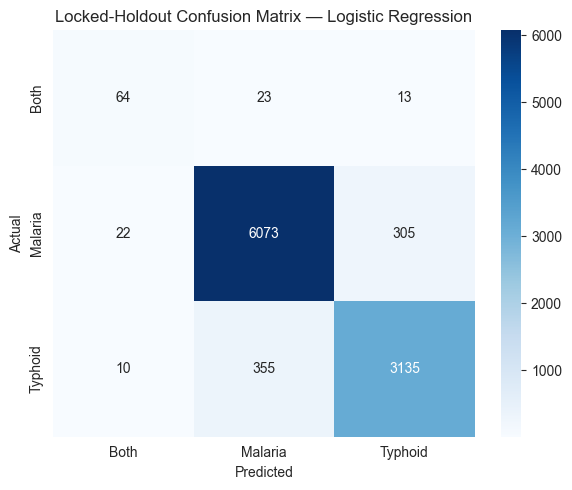

In [21]:

winner_predictions = holdout_predictions[winner_name]
winner_probabilities = holdout_probabilities[winner_name]

class_report = pd.DataFrame(
    classification_report(
        y_holdout,
        winner_predictions,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0,
    )
).T
display(class_report.style.format(precision=3))

matrix = confusion_matrix(y_holdout, winner_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title(f"Locked-Holdout Confusion Matrix — {winner_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### 3.4 Model Interpretation

Permutation importance measures the reduction in holdout macro F1 after each feature is shuffled. The calculation uses a reproducible holdout subsample and therefore reflects the fitted model's dependence on each predictor under the selected scoring rule.

Importance values are model- and dataset-specific. They do not measure causality, biological relevance, or real-world clinical importance, and correlated predictors may divide importance between themselves.

,Feature,Importance_Mean,Importance_SD
32,Yellow_Eyes,0.0585,0.0166
14,Abdominal_Pain,0.0443,0.0137
26,Anemia,0.0423,0.0185
1,Fatigue,0.0384,0.0085
41,Temperature,0.0372,0.0125
33,Eye_Pain,0.0352,0.0195
10,Dizziness,0.0333,0.0040
38,Back_Pain,0.0317,0.0101
20,Seizures,0.0308,0.0131
30,Rash,0.0306,0.0102


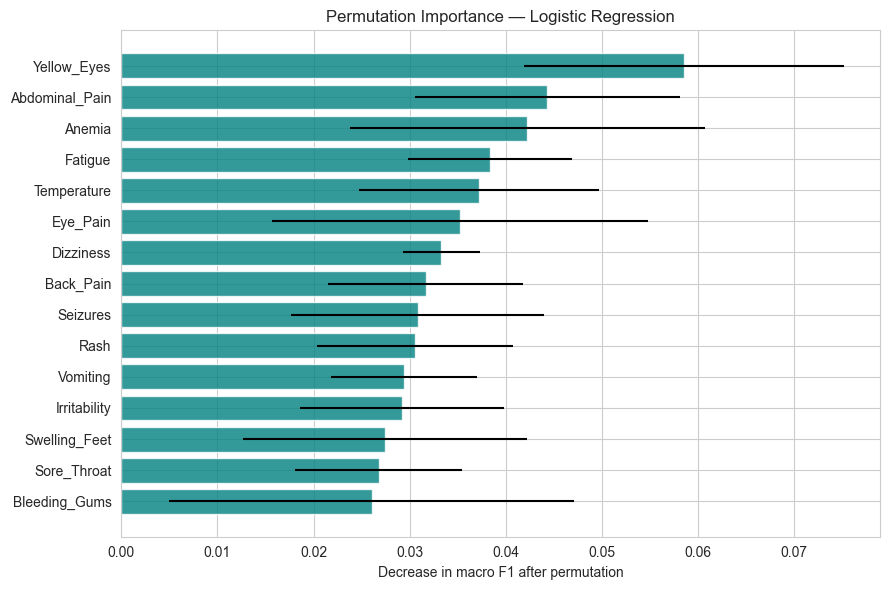

In [22]:

importance_rng = np.random.default_rng(RANDOM_STATE)
importance_positions = importance_rng.choice(
    len(X_holdout),
    size=min(2500, len(X_holdout)),
    replace=False,
)
importance_sample = X_holdout.iloc[importance_positions]
importance_targets = y_holdout[importance_positions]
importance = permutation_importance(
    winner,
    importance_sample,
    importance_targets,
    scoring="f1_macro",
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importance_table = (
    pd.DataFrame({
        "Feature": model_features,
        "Importance_Mean": importance.importances_mean,
        "Importance_SD": importance.importances_std,
    })
    .sort_values("Importance_Mean", ascending=False)
    .head(15)
)
display(importance_table.style.format({
    "Importance_Mean": "{:.4f}",
    "Importance_SD": "{:.4f}",
}))

plt.figure(figsize=(9, 6))
plot_data = importance_table.sort_values("Importance_Mean")
plt.barh(
    plot_data["Feature"],
    plot_data["Importance_Mean"],
    xerr=plot_data["Importance_SD"],
    color="teal",
    alpha=0.8,
)
plt.title(f"Permutation Importance — {winner_name}")
plt.xlabel("Decrease in macro F1 after permutation")
plt.tight_layout()
plt.show()


### 3.5 In-Memory Inference Validation

A small inference check confirms that the selected pipeline applies its fitted preprocessing and classifier without refitting. Predicted class probabilities are displayed for example holdout records and verified to sum to one.

This is a technical pipeline check only; it is not prospective or external validation.

In [23]:

example_patients = X_holdout.iloc[:5].copy()
example_probabilities = winner.predict_proba(example_patients)
example_predictions = label_encoder.inverse_transform(
    winner.predict(example_patients)
)

inference_results = pd.DataFrame(
    example_probabilities,
    columns=[f"Probability_{name}" for name in label_encoder.classes_],
    index=example_patients.index,
)
inference_results.insert(0, "Prediction", example_predictions)
inference_results.insert(
    0,
    "Actual",
    label_encoder.inverse_transform(y_holdout[:5]),
)
display(inference_results.style.format(precision=4))
assert np.allclose(example_probabilities.sum(axis=1), 1.0)


,Actual,Prediction,Probability_Both,Probability_Malaria,Probability_Typhoid
10120,Malaria,Malaria,0.0002,0.9735,0.0262
24462,Malaria,Malaria,0.0002,0.9884,0.0114
17501,Malaria,Malaria,0.0008,0.9779,0.0213
7589,Malaria,Malaria,0.0000,0.9991,0.0009
9262,Malaria,Malaria,0.0010,0.9048,0.0942


## 4. Conclusions, Limitations, and Next Steps

### 4.1 Main Finding

Logistic Regression achieved the strongest cross-validated macro F1 among the evaluated candidates and retained competitive performance on the locked holdout set. Moderate weighting of the co-infection class improved minority-class recall while maintaining strong performance for Malaria and Typhoid. Within this benchmark, the linear model offers the best balance of performance, speed, and interpretability.

### 4.2 Limitations

The results are constrained by several important limitations:

1. **Synthetic data:** Performance measures recovery of the generator's assumptions, not clinical diagnostic validity.
2. **Closed target set:** The dataset contains no `Neither` or `Other febrile illness` class, so it does not represent realistic differential diagnosis.
3. **Limited clinical context:** Age, sex, pregnancy status, symptom duration, treatment history, comorbidities, geography, and seasonality are absent.
4. **No external validation:** All records originate from one synthetic process.
5. **No clinical threshold analysis:** Model probabilities have not been calibrated or linked to the relative harms of false-negative and false-positive decisions.

### 4.3 Recommended Next Steps

Before any clinical interpretation or deployment, the project should:

- obtain representative, ethically governed, laboratory-confirmed patient data;
- include other causes of febrile illness and a clinically meaningful reference standard;
- perform temporal and site-level external validation;
- report confidence intervals, calibration, subgroup performance, and precision-recall curves;
- select decision thresholds with clinicians based on explicit error costs; and
- conduct prospective workflow and patient-safety evaluation.

> **Final conclusion:** The notebook now demonstrates a sound machine-learning evaluation pattern for a synthetic benchmark. It does not establish a clinically validated malaria or typhoid diagnostic system.